In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# [Part 1] 신경망 아키텍처(구조) 도식화 (1 -> 4 -> 2)

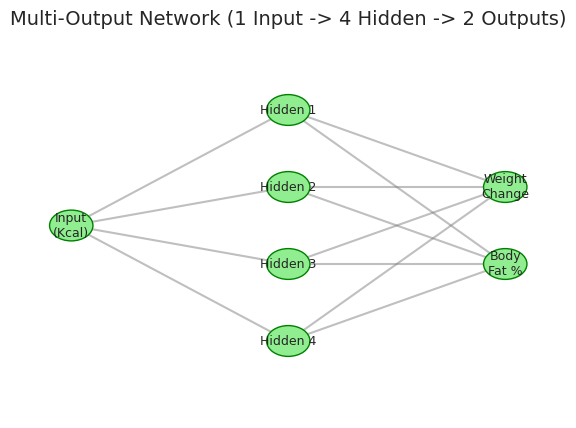

In [2]:
def draw_neural_net(layer_sizes):
    fig = plt.figure(figsize=(7, 5))
    ax = fig.gca()
    ax.axis('off')
    
    left, right, bottom, top = 0.1, 0.9, 0.1, 0.9
    v_spacing = (top - bottom) / float(max(layer_sizes))
    h_spacing = (right - left) / float(len(layer_sizes) - 1)
    
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing * (layer_size - 1) / 2. + (top + bottom) / 2.
        for m in range(layer_size):
            circle = plt.Circle((n * h_spacing + left, layer_top - m * v_spacing), 
                                v_spacing / 5., color='lightgreen', ec='green', zorder=4)
            ax.add_artist(circle)
            if n == 0: text = f'Input\n(Kcal)'
            elif n == 1: text = f'Hidden {m+1}'
            elif n == 2 and m == 0: text = f'Weight\nChange'
            elif n == 2 and m == 1: text = f'Body\nFat %'
            ax.text(n * h_spacing + left, layer_top - m * v_spacing, text, 
                    ha='center', va='center', fontsize=9, zorder=5)
            
            if n > 0:
                prev_layer_top = v_spacing * (layer_sizes[n-1] - 1) / 2. + (top + bottom) / 2.
                for o in range(layer_sizes[n-1]):
                    line = plt.Line2D([n * h_spacing + left, (n - 1) * h_spacing + left],
                                      [layer_top - m * v_spacing, prev_layer_top - o * v_spacing], c='gray', alpha=0.5)
                    ax.add_artist(line)
                    
    plt.title("Multi-Output Network (1 Input -> 4 Hidden -> 2 Outputs)", fontsize=14)
    plt.show()

draw_neural_net([1, 4, 2])

# [Part 2] 콘솔로 보는 단계별 행렬 계산 (Forward Pass)

In [3]:
print("=== [Part 2] 다중 출력 신경망 계산 시뮬레이션 ===\n")

# 1. 입력 데이터: 2500 kcal 섭취 (계산 편의상 1000단위로 나누어 2.5로 투입)
X_single = np.array([[2.5]]) 
print(f"1. 투입 데이터 X (Shape: {X_single.shape})\n{X_single} (의미: 2500 kcal)\n")

# 2. 은닉층 파라미터: 1개의 입력을 4개의 노드로 쪼갭니다. (1x4 행렬)
W1 = np.array([[ 0.8, -0.5, 1.2, -0.2]]) 
b1 = np.array([-0.5,  0.2, 0.1,  0.5])

Z1_single = np.dot(X_single, W1) + b1
print(f"2. 선형 변환 후 Z1 = X*W1 + b1 (Shape: {Z1_single.shape})\n{Z1_single}\n")

# 3. 활성화 함수 (ReLU 적용: 음수는 0으로 뭉갬)
H1_single = np.maximum(0, Z1_single)
print(f"3. ReLU 활성화 후 H1 = max(0, Z1) (Shape: {H1_single.shape})\n{H1_single}\n")

# 4. 출력층 파라미터: 4개의 특징을 2개의 정답(체중 변화, 체지방률)으로 모읍니다. (4x2 행렬)
# 첫 번째 열은 '체중 변화'에, 두 번째 열은 '체지방률'에 기여하는 가중치입니다.
W2 = np.array([[ 1.5,  0.8], 
               [-1.0, -0.5], 
               [ 0.7,  1.2], 
               [-0.2, -0.1]])
# 기본 체중 변화량(0kg)과 기본 체지방률(15%)을 편향(Bias)으로 설정
b2 = np.array([0.0, 15.0]) 

Output_single = np.dot(H1_single, W2) + b2
print(f"4. 최종 예측값 Output = H1*W2 + b2 (Shape: {Output_single.shape})\n{Output_single}\n")
print(f"👉 결론: 2500kcal 섭취 시 예측 체중 변화량은 {Output_single[0][0]:.2f}kg, 체지방률은 {Output_single[0][1]:.2f}% 입니다.")

=== [Part 2] 다중 출력 신경망 계산 시뮬레이션 ===

1. 투입 데이터 X (Shape: (1, 1))
[[2.5]] (의미: 2500 kcal)

2. 선형 변환 후 Z1 = X*W1 + b1 (Shape: (1, 4))
[[ 1.5  -1.05  3.1   0.  ]]

3. ReLU 활성화 후 H1 = max(0, Z1) (Shape: (1, 4))
[[1.5 0.  3.1 0. ]]

4. 최종 예측값 Output = H1*W2 + b2 (Shape: (1, 2))
[[ 4.42 19.92]]

👉 결론: 2500kcal 섭취 시 예측 체중 변화량은 4.42kg, 체지방률은 19.92% 입니다.


# [Part 3] 입력값(칼로리) 변화에 따른 두 출력값의 동시 시각화

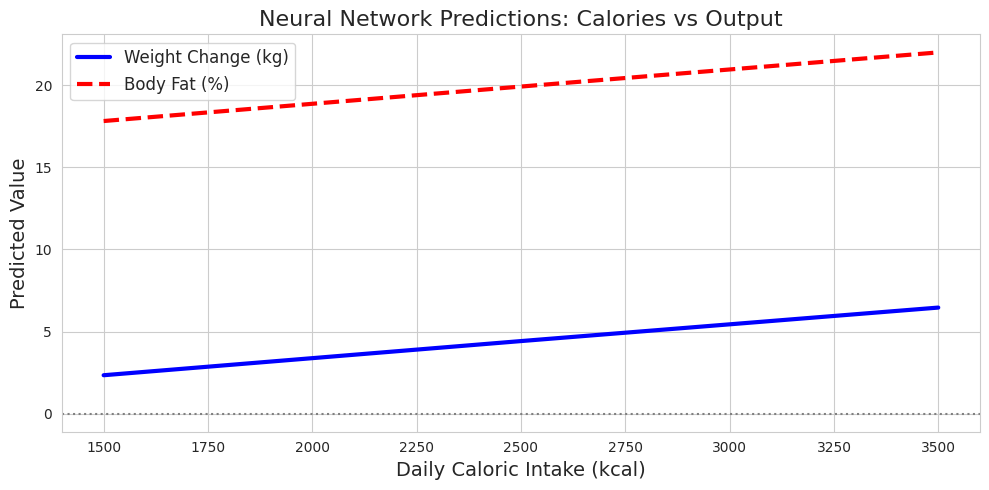

In [4]:
# 1500kcal(1.5)부터 3500kcal(3.5)까지 100개의 가상 데이터를 한 번에 투입
X_range = np.linspace(1.5, 3.5, 100).reshape(-1, 1)

# 신경망 전체 공정을 한 줄로 통과시킴
Z1_range = np.dot(X_range, W1) + b1
H1_range = np.maximum(0, Z1_range)
Output_range = np.dot(H1_range, W2) + b2

# 결과 시각화
plt.figure(figsize=(10, 5))

# 출력 1: 체중 변화량 (파란색 선)
plt.plot(X_range * 1000, Output_range[:, 0], color='blue', linewidth=3, label='Weight Change (kg)')
# 출력 2: 체지방률 (빨간색 선) - 스케일이 다르므로 보조축(Twinx) 사용도 가능하지만 직관성을 위해 그냥 그림
plt.plot(X_range * 1000, Output_range[:, 1], color='red', linewidth=3, linestyle='--', label='Body Fat (%)')

plt.title('Neural Network Predictions: Calories vs Output', fontsize=16)
plt.xlabel('Daily Caloric Intake (kcal)', fontsize=14)
plt.ylabel('Predicted Value', fontsize=14)
plt.axhline(0, color='gray', linestyle=':', linewidth=1.5) # 0 기준선
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()